In [1]:
import gzip
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,cross_val_predict,  KFold,  LeaveOneOut, StratifiedKFold

### Construct Testosterone PGS for UK Biobank

##### Extract METAL trans-ancestry variants

In [4]:
# metal snps
metal_snps=pd.read_csv("../data/metal/METAANALYSIS1.TBL.filt",delimiter="\t")
metal_snps=metal_snps[metal_snps["P-value"]<.00000005]["MarkerName"].tolist()
metal_snps_chr_bp=[x.rsplit(":",2)[0] for x in metal_snps]
print(len(metal_snps))

#rsid dataframe
rsid=pd.read_csv("/cellar/users/mpagadal/resources/rsid/hg19_avsnp147.txt",header=None,delimiter="\t")
rsid["variant"]=rsid[0].astype(str)+":"+rsid[1].astype(str)
rsid_filt=rsid[rsid["variant"].isin(metal_snps_chr_bp)]

compiled_rsid=pd.DataFrame()

for i,row in metal_snps_sig.iterrows():
    print(row["variant"])
    rsid_filt=rsid[rsid["variant"]==row["variant"]]
    compiled_rsid=compiled_rsid.append(rsid_filt)

compiled_rsid_clean=pd.DataFrame()

for i,row in metal_snps_sig.iterrows():
    compiled_rsid_filt = compiled_rsid[compiled_rsid["variant"]==row["variant"]]
    compiled_rsid_filt = compiled_rsid_filt[(compiled_rsid_filt[3]==row["major"])|(compiled_rsid_filt[4]==row["major"])]
    compiled_rsid_filt = compiled_rsid_filt[(compiled_rsid_filt[3]==row["minor"])|(compiled_rsid_filt[4]==row["minor"])]
    compiled_rsid_clean=compiled_rsid_clean.append(compiled_rsid_filt)

extract=compiled_rsid_clean[5].tolist()+["rs113017476","rs1042554135"]
pd.DataFrame({"extract":extract}).to_csv("../scripts/extract.metal.prs.snps.txt",header=None,index=None,sep="\t")


46


/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3049: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


NameError: name 'metal_snps_sig' is not defined

In [5]:
metal_snps

['2:27730940:T:C',
 '3:138020648:G:A',
 '16:28868695:G:A',
 'X:67045153:T:C',
 '1:40035928:G:T',
 'X:109749735:ACT:A',
 '1:27180088:A:C',
 'X:67403723:T:G',
 '2:11734814:T:TTTG',
 '12:2908330:C:A',
 '17:29707502:C:A',
 '10:65065272:C:CCTCT',
 '17:7412675:T:A',
 'X:109887142:G:C',
 '19:46396507:T:A',
 '17:7531252:T:TC',
 '2:32681099:G:T',
 '16:53800954:T:C',
 '10:65224200:G:GA',
 '17:47391290:T:C',
 '12:21331549:T:C',
 '6:32658310:G:A',
 '4:69533221:A:T',
 'X:64708833:T:C',
 'X:8901390:G:A',
 '7:97984321:TG:T',
 '15:53739426:A:C',
 '10:64887856:C:T',
 '22:44324727:C:G',
 '19:17346854:G:C',
 '15:96708291:T:C',
 'X:109761039:G:GT',
 'X:109883087:T:C',
 '17:7549080:AAAT:A',
 'X:67138963:T:C',
 '12:121416622:C:G',
 'X:64885603:T:A',
 '2:31989359:GGAGTATGTTCTTGCTGAT:AGAGTATGTTCTTGCTGAT',
 '17:7773418:G:A',
 '14:94838142:G:T',
 '17:7533015:C:T',
 'X:8912628:C:T',
 '7:9714084:G:A',
 '17:7329785:C:T',
 'X:8916646:A:C',
 '17:1653091:G:A']

#### run ../scripts/recode.sh

In [161]:
#dosage file of index snps
raw=pd.read_csv("../data/ukbb-prs/testosterone.metal.raw",delimiter="\t")
raw=raw.set_index("FID")
raw=raw.T
raw["min_allele"]=raw.index.str.split("_").str[-1]
raw=raw.reset_index()
raw=raw.rename(columns={"index":"ID"})
raw["ID"]=raw["ID"].str.split("_").str[0]

mapping=compiled_rsid_clean[compiled_rsid_clean[5].isin(raw["ID"].tolist())]
mapping["ID"]=mapping[0].astype(str)+":"+mapping[1].astype(str)+":"+mapping[3]+":"+mapping[4]
mapping["ID2"]=mapping[0].astype(str)+":"+mapping[1].astype(str)+":"+mapping[4]+":"+mapping[3]

mp_map={}

for i,row in mapping.iterrows():
    mp_map[row["ID"]]=row[5]
    mp_map[row["ID2"]]=row[5]

mp_map["2:31989359:A:G"]="rs113017476"
mp_map["2:31989359:G:A"]="rs113017476"
mp_map['2:31989359:GGAGTATGTTCTTGCTGAT:AGAGTATGTTCTTGCTGAT']="rs113017476"

In [168]:
mp_map={}

for i,row in mapping.iterrows():
    mp_map[row["ID"]]=row[5]
    mp_map[row["ID2"]]=row[5]

mp_map["2:31989359:A:G"]="rs113017476"
mp_map["2:31989359:G:A"]="rs113017476"
mp_map['2:31989359:GGAGTATGTTCTTGCTGAT:AGAGTATGTTCTTGCTGAT']="rs113017476"

### Get summary statistics

In [169]:
stats=pd.read_csv("../discovery/data/summarystats/significant/compiled.eur.all.variant.glm.linear",delimiter="\t")
stats.head()

,#CHROM,POS,ID,REF,ALT,A1,TEST,OBS_CT,BETA,SE,T_STAT,P
0,19,17346854,19:17346854:G:C,G,C,C,ADD,89047,0.085513,0.012705,6.73046,1.701440e-11
1,14,94838142,14:94838142:G:T,G,T,T,ADD,89047,0.236066,0.017676,13.35540,1.206010e-40
2,22,29060218,22:29060218:C:A,C,A,A,ADD,89047,-0.008242,0.007822,-1.05362,2.920600e-01
3,4,69533221,4:69533221:A:T,A,T,T,ADD,89047,0.028175,0.004957,5.68385,1.321040e-08
4,12,21331549,12:21331549:T:C,T,C,C,ADD,89047,-0.043667,0.006472,-6.74728,1.515600e-11


In [170]:
stats["ID"]=stats["ID"].map(mp_map)

In [171]:
stats_filt=stats[~stats["ID"].isnull()]

In [172]:
len(stats_filt)

34

### align stats

In [173]:
raw_prs=pd.merge(raw,stats_filt[["ID","ALT","BETA"]],on="ID",how="left")

In [174]:
#switch BETA to align
raw_prs["BETA"]=np.where(raw_prs["min_allele"]!=raw_prs["ALT"],raw_prs["BETA"]*-1,raw_prs["BETA"])

In [175]:
print(raw_prs.shape)
raw_prs.head()

(34, 487413)


,ID,5309711,5607583,3534526,5138852,2187179,5443098,5796294,1412208,2623961,...,2472951,1594720,3387495,1801702,4639336,2621795,5235209,min_allele,ALT,BETA
0,rs75460349,2.00000,2.0,2.0,2.0,2.0,2.0000,2.0,2.0000,2.0000,...,2.0000,2.0,2.0,2.0000,2.0,1.9961,2.0,A,C,0.094969
1,rs3768321,2.00000,2.0,2.0,2.0,2.0,2.0000,1.0,2.0000,1.0000,...,1.9961,2.0,1.0,2.0000,1.0,2.0000,2.0,G,T,0.038822
2,rs111264548,0.00000,0.0,1.0,2.0,2.0,0.9961,2.0,0.9961,1.1843,...,1.0039,1.0,2.0,1.9961,1.0,0.0000,1.0,T,TTTG,-0.027051
3,rs1260326,0.00000,0.0,0.0,0.0,1.0,0.0000,1.0,0.0000,1.0000,...,0.0000,0.0,0.0,0.0000,0.0,2.0000,0.0,T,C,0.039601
4,rs113017476,1.03925,2.0,2.0,2.0,2.0,2.0000,2.0,2.0000,2.0000,...,2.0000,2.0,2.0,2.0000,2.0,2.0000,2.0,G,A,-0.097568


### align such that BETA is increasing

In [176]:
switch=[]

for i,row in raw_prs.iterrows():
    if row["BETA"]<0:
        switch.append(row["ID"])

In [177]:
raw_prs=raw_prs.set_index("ID")
del raw_prs["min_allele"]
del raw_prs["ALT"]

In [178]:
raw_flip=raw_prs.iloc[:,:-1].T

In [179]:
for x in switch:
    print("switching alleles for {}".format(x))
    raw_flip[x]=2-raw_flip[x]

switching alleles for rs111264548
switching alleles for rs113017476
switching alleles for rs72800804
switching alleles for rs989075
switching alleles for rs35290825
switching alleles for rs56196860
switching alleles for rs112635299
switching alleles for rs8023580
switching alleles for rs3976
switching alleles for rs188272638
switching alleles for rs148963195
switching alleles for rs62059839
switching alleles for rs202200760
switching alleles for rs12976390
switching alleles for rs738409
switching alleles for rs59585459
switching alleles for rs139036121
switching alleles for rs373105027


In [180]:
raw_flip=raw_flip.T

In [181]:
raw_flip=pd.merge(raw_flip,raw_prs[["BETA"]],left_index=True,right_index=True)

In [182]:
raw_flip["BETA"]=abs(raw_flip["BETA"])

In [183]:
prs=raw_flip.iloc[:,:-1].mul(raw_flip["BETA"],axis=0).sum().reset_index()

In [184]:
prs.columns=["FID","PRS"]

In [185]:
prs.head()

,FID,PRS
0,5309711,5.332615
1,5607583,5.441544
2,3534526,5.415158
3,5138852,4.985306
4,2187179,5.266064


### Get phenotypes

In [186]:
pheno=pd.read_csv("../validation/data/UKBB/phenotypes/pheno.tsv",delimiter="\t")
pheno=pheno[pheno["Testosterone"]!=-9]
pheno["FID"]=pheno["FID"].astype(int)
pheno.head()

,FID,IID,Testosterone
1,2666253,2666253.0,12.258
2,3290256,3290256.0,14.872
3,2871598,2871598.0,8.954
4,1035210,1035210.0,17.106
5,1661667,1661667.0,14.767


In [187]:
mp_testosterone=dict(zip(pheno["FID"],pheno["Testosterone"]))

In [188]:
prs["testosterone"]=prs["FID"].map(mp_testosterone)

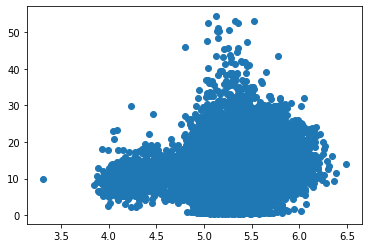

In [189]:
plt.scatter(prs["PRS"],prs["testosterone"])

## get phecode information

In [194]:
prs=prs.rename(columns={"index":"FID"})

In [195]:
phecode=pd.read_csv("../validation/data/UKBB/phenotypes/pheno.phecode.tsv",delimiter="\t")

In [196]:
prs=pd.merge(prs,phecode,on="FID",how="left")

In [197]:
prs.to_csv("eur.metal.testosterone.prs.tsv",index=None,sep="\t")